# AQI Forecasting — XGBoost Model (Hourly)
**Dataset:** `AnandVihar_AQI_cleaned.csv`  
**Target:** Hourly AQI  
**Model:** XGBoost with hourly lag features · pollutant/weather columns · cyclic calendar encoding  

> **EDA-driven decisions (Section 10 of EDA notebook):**
> - *Granularity:* **Hourly** — EDA confirms XGBoost benefits from more rows (43,812 rows vs 1,826 daily)
> - *Features:* PM25, PM10, CO, NOx (r > 0.6 with AQI); O3 and WS are negative correlators
> - *Lags:* Hourly lag_1h through lag_48h; ACF lag-1 r ≈ 0.887 (very strong autocorrelation)
> - *Cyclic encoding:* Hour_sin/cos, Month_sin/cos, DOW_sin/cos, DayOfYear_sin/cos
> - *Split:* 70% train / 15% validation / 15% test — **time-based**, no random shuffling
> - *Stationarity:* Not required for XGBoost (non-parametric)


## 0. Install & Import

In [37]:
# Install xgboost if not present
try:
    import xgboost
    print(f'xgboost {xgboost.__version__} already installed.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])
    print('xgboost installed — restart kernel if import still fails.')

xgboost 2.1.3 already installed.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score)
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

print('Libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')

Libraries loaded successfully.
XGBoost version: 2.1.3


## 1. Load & Preprocess Data
Using **hourly** granularity as recommended by EDA (Section 10.2).  
The dataset covers Jan 2021 – Dec 2025 with 43,809 hourly rows and 20 pollutant/weather features.


In [39]:
# ── Path — change only this line when switching city ──────────────────────
STATION_NAME = 'AnandVihar'
DATA_PATH    = f'D:\\AQI_Project\\data\\clean\\{STATION_NAME}_AQI_cleaned.csv'
OUTPUT_DIR   = 'saved_models'
os.makedirs('images',    exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)

# Load hourly CSV
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Columns     : {df.columns.tolist()}')
print(f'Null count  : {df.isnull().sum().sum()}')
df.head(3)


Shape       : (43812, 20)
Date range  : 2021-01-01 12:00:00  →  2025-12-31 23:00:00
Columns     : ['Timestamp', 'NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WS', 'WD', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']
Null count  : 0


,Timestamp,NO,NOx,Benzene,Toluene,AT,RH,WS,WD,SR,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 12:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,127.97,56.31,127.97,Moderate
1,2021-01-01 13:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,126.04,56.21,126.04,Moderate
2,2021-01-01 14:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,123.50,57.75,123.50,Moderate


In [40]:
# Coerce numerics and time-interpolate any remaining gaps
for col in df.select_dtypes(include='number').columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.set_index('Timestamp').sort_index()

num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols] = df[num_cols].interpolate(method='time')

print(f'Null count after interpolation: {df.isnull().sum().sum()}')
print(df.head(3))

Null count after interpolation: 0
                         NO     NOx  Benzene  Toluene    AT     RH    WS  \
Timestamp                                                                  
2021-01-01 12:00:00  131.36  169.79    10.57     93.7  14.3  74.83  0.49   
2021-01-01 13:00:00  131.36  169.79    10.57     93.7  14.3  74.83  0.49   
2021-01-01 14:00:00  131.36  169.79    10.57     93.7  14.3  74.83  0.49   

                         WD      SR      BP   PM25    PM10     NO2    SO2  \
Timestamp                                                                   
2021-01-01 12:00:00  142.19  155.31  972.25  431.5  416.35  132.02  36.03   
2021-01-01 13:00:00  142.19  155.31  972.25  431.5  416.35  132.02  36.03   
2021-01-01 14:00:00  142.19  155.31  972.25  431.5  416.35  132.02  36.03   

                       NH3      CO     O3     AQI AQI_Category  
Timestamp                                                       
2021-01-01 12:00:00  14.61  127.97  56.31  127.97     Moderate  
2021

## 2. Feature Engineering
Per EDA Section 10.4, XGBoost on hourly data uses:
- **Lag features**: lag_1h … lag_48h (ACF shows strong autocorrelation up to 24h+)
- **Rolling statistics**: 3h, 6h, 24h rolling mean and std (shift 1 to avoid leakage)
- **Cyclic calendar**: Hour_sin/cos, Month_sin/cos, DOW_sin/cos, DayOfYear_sin/cos
- **Categorical**: IsWeekend, Season_Enc (0–3), aqi_cat_enc (0–5)
- **Pollutant sub-indices**: all 13 pollutant columns (PM25, PM10, CO, NOx, …)
- **Weather features**: AT, RH, WS, WD, TOT-RF, SR, BP
  - EDA Section 10.5: WS shows negative correlation with AQI (wind disperses pollutants)


In [41]:
# ── Candidate feature lists (only kept if column exists in this dataset) ──
# AnandVihar has: NO, NOx, Benzene, Toluene, PM25, PM10, NO2, SO2, NH3, CO, O3
# Not present: Eth-Benzene, MP-Xylene (Colaba-only), Toluene replaces them here
_pollutant_candidates = ['NO','NOx','Benzene','Toluene',
                          'PM25','PM10','NO2','SO2','NH3','CO','O3']
# AnandVihar weather: AT, RH, WS, WD, SR, BP  (no TOT-RF in this dataset)
_weather_candidates   = ['AT','RH','WS','WD','SR','BP']

pollutant_cols = [c for c in _pollutant_candidates if c in df.columns]
weather_cols   = [c for c in _weather_candidates   if c in df.columns]

print(f'Pollutant features ({len(pollutant_cols)}): {pollutant_cols}')
print(f'Weather features   ({len(weather_cols)}): {weather_cols}')


Pollutant features (11): ['NO', 'NOx', 'Benzene', 'Toluene', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
Weather features   (6): ['AT', 'RH', 'WS', 'WD', 'SR', 'BP']


In [42]:
def create_hourly_features(df_in):
    """
    Build the full XGBoost feature matrix from hourly AQI data.
    Aligned with EDA Sections 10.4 and 10.5 recommendations.
    """
    df_f = df_in.copy()

    # ── Lag features (hourly) ─────────────────────────────────────────────
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df_f[f'lag_{lag}h'] = df_f['AQI'].shift(lag)

    # ── Rolling statistics (shift 1 to avoid leakage) ────────────────────
    for win in [3, 6, 24]:
        df_f[f'roll_mean_{win}h'] = df_f['AQI'].shift(1).rolling(win).mean()
        df_f[f'roll_std_{win}h']  = df_f['AQI'].shift(1).rolling(win).std()

    # ── Cyclic calendar features ──────────────────────────────────────────
    df_f['hour']        = df_f.index.hour
    df_f['day_of_week'] = df_f.index.dayofweek
    df_f['month']       = df_f.index.month
    df_f['day_of_year'] = df_f.index.dayofyear

    df_f['hour_sin']  = np.sin(2 * np.pi * df_f['hour']        / 24)
    df_f['hour_cos']  = np.cos(2 * np.pi * df_f['hour']        / 24)
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['month']       / 12)
    df_f['month_cos'] = np.cos(2 * np.pi * df_f['month']       / 12)
    df_f['dow_sin']   = np.sin(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['dow_cos']   = np.cos(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['doy_sin']   = np.sin(2 * np.pi * df_f['day_of_year'] / 365)
    df_f['doy_cos']   = np.cos(2 * np.pi * df_f['day_of_year'] / 365)

    # ── Boolean / encoded categoricals ───────────────────────────────────
    df_f['is_weekend'] = (df_f['day_of_week'] >= 5).astype(int)

    season_map = {12:0, 1:0, 2:0,   # Winter=0
                  3:1,  4:1, 5:1,   # Spring=1
                  6:2,  7:2, 8:2,   # Summer=2
                  9:3, 10:3, 11:3}  # Autumn=3
    df_f['season_enc'] = df_f['month'].map(season_map)

    if 'AQI_Category' in df_f.columns:
        cat_enc = {'Good':0,'Satisfactory':1,'Moderate':2,
                   'Poor':3,'Very Poor':4,'Severe':5}
        df_f['aqi_cat_enc'] = df_f['AQI_Category'].map(cat_enc)
        df_f = df_f.drop(columns=['AQI_Category'], errors='ignore')

    return df_f


featured = create_hourly_features(df)
featured = featured.dropna()   # drop rows where lag/rolling are NaN

DROP_COLS    = ['AQI']
feature_cols = [c for c in featured.columns if c not in DROP_COLS]

print(f'Total samples after lag drop : {len(featured):,}')
print(f'Feature count                : {len(feature_cols)}')
print('Features:')
for f in feature_cols:
    print(f'  • {f}')

Total samples after lag drop : 43,764
Feature count                : 45
Features:
  • NO
  • NOx
  • Benzene
  • Toluene
  • AT
  • RH
  • WS
  • WD
  • SR
  • BP
  • PM25
  • PM10
  • NO2
  • SO2
  • NH3
  • CO
  • O3
  • lag_1h
  • lag_2h
  • lag_3h
  • lag_6h
  • lag_12h
  • lag_24h
  • lag_48h
  • roll_mean_3h
  • roll_std_3h
  • roll_mean_6h
  • roll_std_6h
  • roll_mean_24h
  • roll_std_24h
  • hour
  • day_of_week
  • month
  • day_of_year
  • hour_sin
  • hour_cos
  • month_sin
  • month_cos
  • dow_sin
  • dow_cos
  • doy_sin
  • doy_cos
  • is_weekend
  • season_enc
  • aqi_cat_enc


## 3. Train / Validation / Test Split (Temporal — 70 / 15 / 15)
EDA Section 10.7: **always use time-based chronological splits** — random splits cause data leakage for all AQI models.


In [43]:
featured['AQI_next'] = featured['AQI'].shift(-1)
featured = featured.dropna(subset=['AQI_next'])

n         = len(featured)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = featured.iloc[:train_end]
val   = featured.iloc[train_end:val_end]
test  = featured.iloc[val_end:]

X_train = train[feature_cols];  y_train = train['AQI_next']
X_val   = val[feature_cols];    y_val   = val['AQI_next']
X_test  = test[feature_cols];   y_test  = test['AQI_next']

print(f'Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train):,} rows)')
print(f'Val   : {val.index[0].date()}   → {val.index[-1].date()}   ({len(val):,} rows)')
print(f'Test  : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test):,} rows)')

Train : 2021-01-03 → 2024-07-02  (30,634 rows)
Val   : 2024-07-02   → 2025-04-02   (6,564 rows)
Test  : 2025-04-02  → 2025-12-31  (6,565 rows)


## 4. Train XGBoost Model
Early stopping on the validation set. `min_child_weight=5` prevents overfitting on the dense hourly data.


In [44]:
model = xgb.XGBRegressor(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.02,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    min_child_weight      = 5,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 100
)

print(f'\nBest iteration : {model.best_iteration}')
print(f'Best val RMSE  : {model.best_score:.4f}')

[0]	validation_0-rmse:125.07739
[100]	validation_0-rmse:19.00765
[200]	validation_0-rmse:8.85144
[300]	validation_0-rmse:8.56884
[336]	validation_0-rmse:8.58537

Best iteration : 286
Best val RMSE  : 8.5641


## 5. Forecast & Evaluation
- **Direct**: uses actual test-period lag values — upper-bound performance.
- **Recursive**: predicted AQI fed back as lag inputs — real-world multi-step scenario.


In [45]:
# ── Direct forecast ──────────────────────────────────────────────────────
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mape = np.mean(np.abs((y_test.values - pred_direct) / (y_test.values + 1e-8))) * 100

print('XGBoost Direct Forecast (hourly):')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')

XGBoost Direct Forecast (hourly):
  RMSE : 6.8419
  MAE  : 3.4324
  MAPE : 2.35%


In [46]:
# ── Recursive (multi-step ahead) forecast ────────────────────────────────
def recursive_forecast(model, train_df, test_df, feature_cols):
    """
    Recursive forecast: predicted AQI is fed back as lag inputs for next steps.
    Pollutant/weather columns retain their actual values.
    """
    all_data    = pd.concat([train_df, test_df]).copy()
    lag_cols    = [c for c in feature_cols if c.startswith('lag_')]
    predictions = []

    for i in range(len(train_df), len(all_data)):
        row  = all_data.iloc[i][feature_cols].values.reshape(1, -1)
        pred = model.predict(row)[0]
        predictions.append(pred)

        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                lag_n = int(lag_col.replace('lag_','').replace('h',''))
                if len(predictions) >= lag_n:
                    all_data.at[all_data.index[i + 1], lag_col] = predictions[-lag_n]

    return np.array(predictions)


pred_recursive = recursive_forecast(model, train, test, feature_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
mape_r = np.mean(np.abs((y_test.values - pred_recursive) / (y_test.values + 1e-8))) * 100

print('XGBoost Recursive Forecast (hourly):')
print(f'  RMSE : {rmse_r:.4f}')
print(f'  MAE  : {mae_r:.4f}')
print(f'  MAPE : {mape_r:.2f}%')

XGBoost Recursive Forecast (hourly):
  RMSE : 7.2368
  MAE  : 3.8613
  MAPE : 2.81%


## 6. Forecast Visualisation

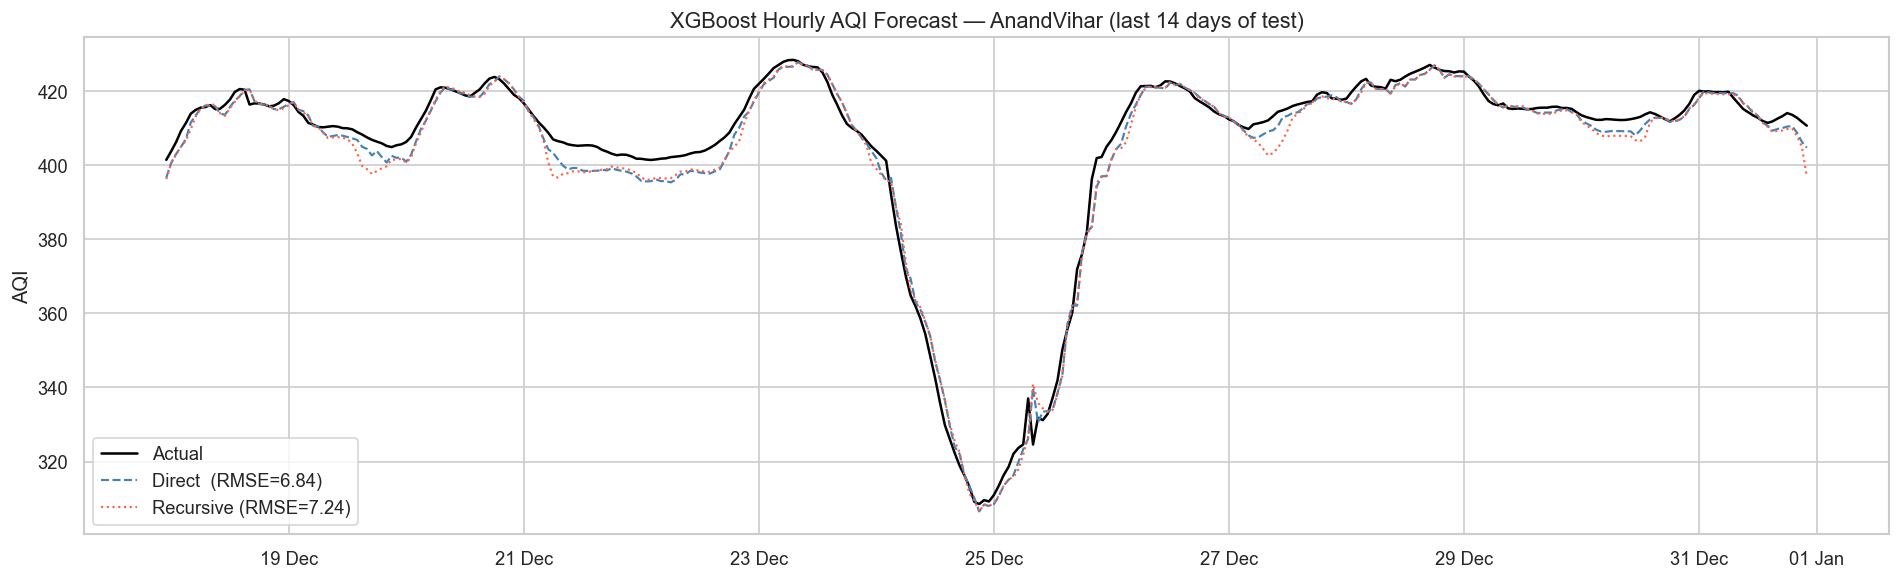

In [47]:
# Plot last 14 days of test for clarity
plot_n = min(14 * 24, len(y_test))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index[-plot_n:], y_test.values[-plot_n:],
        label='Actual', color='black', lw=1.5)
ax.plot(y_test.index[-plot_n:], pred_direct[-plot_n:],
        label=f'Direct  (RMSE={rmse:.2f})', color='steelblue', linestyle='--', lw=1.3)
ax.plot(y_test.index[-plot_n:], pred_recursive[-plot_n:],
        label=f'Recursive (RMSE={rmse_r:.2f})', color='tomato', linestyle=':', lw=1.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title(f'XGBoost Hourly AQI Forecast — {STATION_NAME} (last 14 days of test)', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig(f'images/xgboost_forecast_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

## 7. Feature Importance
EDA final summary predicts top features: PM25, PM10, CO, NOx (r > 0.6 with AQI), lag_1h.


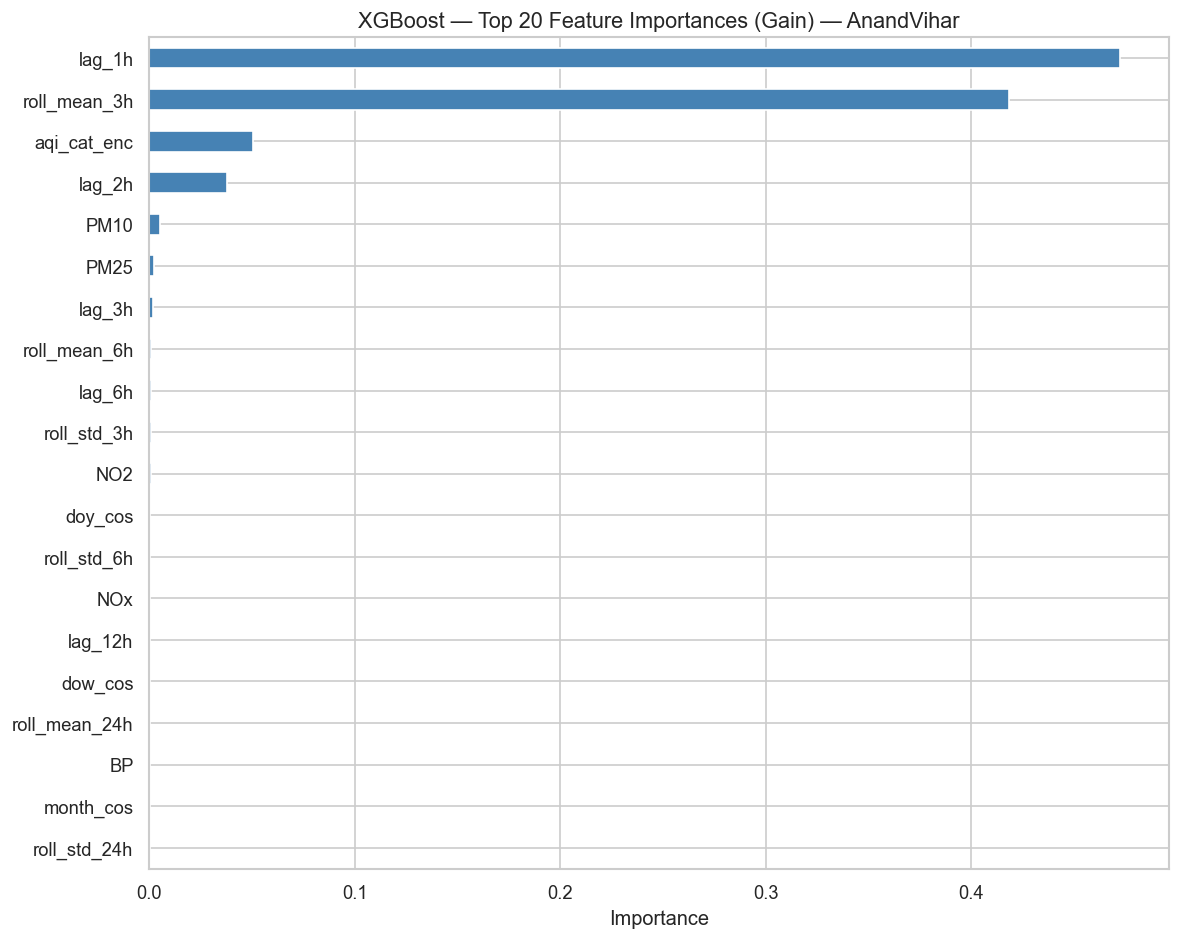

lag_1h           0.472526
roll_mean_3h     0.418312
aqi_cat_enc      0.050222
lag_2h           0.037513
PM10             0.005355
PM25             0.002211
lag_3h           0.001672
roll_mean_6h     0.000730
lag_6h           0.000676
roll_std_3h      0.000628
NO2              0.000613
doy_cos          0.000499
roll_std_6h      0.000465
NOx              0.000460
lag_12h          0.000442
dow_cos          0.000402
roll_mean_24h    0.000355
BP               0.000354
month_cos        0.000331
roll_std_24h     0.000326


In [48]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'XGBoost — Top 20 Feature Importances (Gain) — {STATION_NAME}', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'images/xgboost_feature_importance_{STATION_NAME.lower()}.png', dpi=150)
plt.show()
print(importance.head(20).to_string())

## 8. Learning Curve

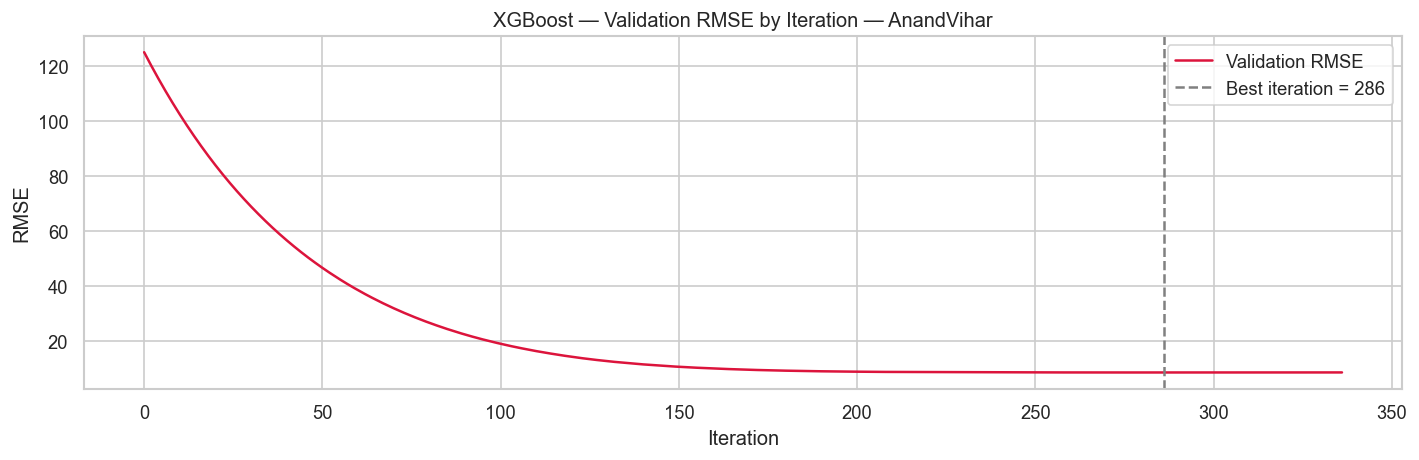

In [49]:
evals_result = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson')
ax.axvline(model.best_iteration, linestyle='--', color='gray',
           label=f'Best iteration = {model.best_iteration}')
ax.set_title(f'XGBoost — Validation RMSE by Iteration — {STATION_NAME}')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'images/xgboost_learning_curve_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

## 9. AQI Category Distribution (Test Set)
Sanity check against EDA Section 2.2 category breakdown.


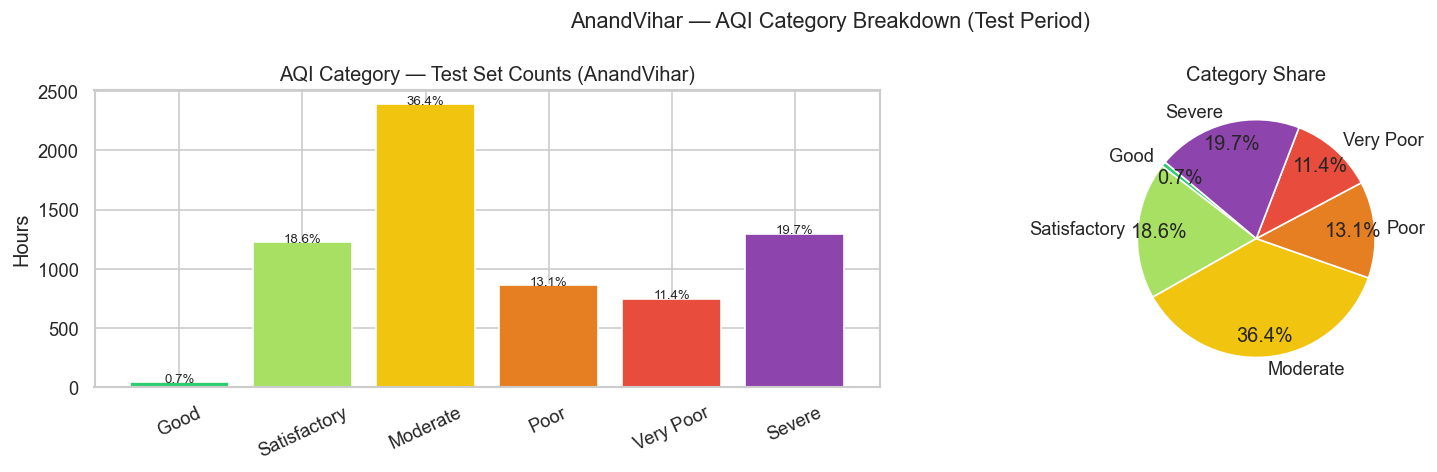

In [50]:
def categorize_aqi(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)


cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
cat_pal   = ['#2ecc71','#a8e063','#f1c40f','#e67e22','#e74c3c','#8e44ad']

y_true_cat = categorize_aqi(y_test.values)
counts = pd.Series(y_true_cat).value_counts().reindex(cat_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(counts.index, counts.values, color=cat_pal, edgecolor='white')
axes[0].set_title(f'AQI Category — Test Set Counts ({STATION_NAME})')
axes[0].set_ylabel('Hours')
axes[0].tick_params(axis='x', rotation=25)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', fontsize=8)

axes[1].pie(counts, labels=cat_order, colors=cat_pal, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82)
axes[1].set_title('Category Share')

plt.suptitle(f'{STATION_NAME} — AQI Category Breakdown (Test Period)', fontsize=13)
plt.tight_layout()
plt.savefig(f'images/xgboost_test_category_dist_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

## 10. Classification Metrics & Confusion Matrix
Converting continuous predictions to discrete AQI categories (Indian standard thresholds) for classification evaluation.


Classification Metrics (AQI Categories — Recursive Forecast):
  Accuracy  : 0.9581
  Precision : 0.9599  (weighted)
  Recall    : 0.9581  (weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.95      0.86      0.90        44
Satisfactory       0.96      0.97      0.96      1224
    Moderate       0.97      0.97      0.97      2392
        Poor       0.95      0.97      0.96       862
   Very Poor       0.86      0.96      0.91       747
      Severe       1.00      0.92      0.96      1296

    accuracy                           0.96      6565
   macro avg       0.95      0.94      0.94      6565
weighted avg       0.96      0.96      0.96      6565



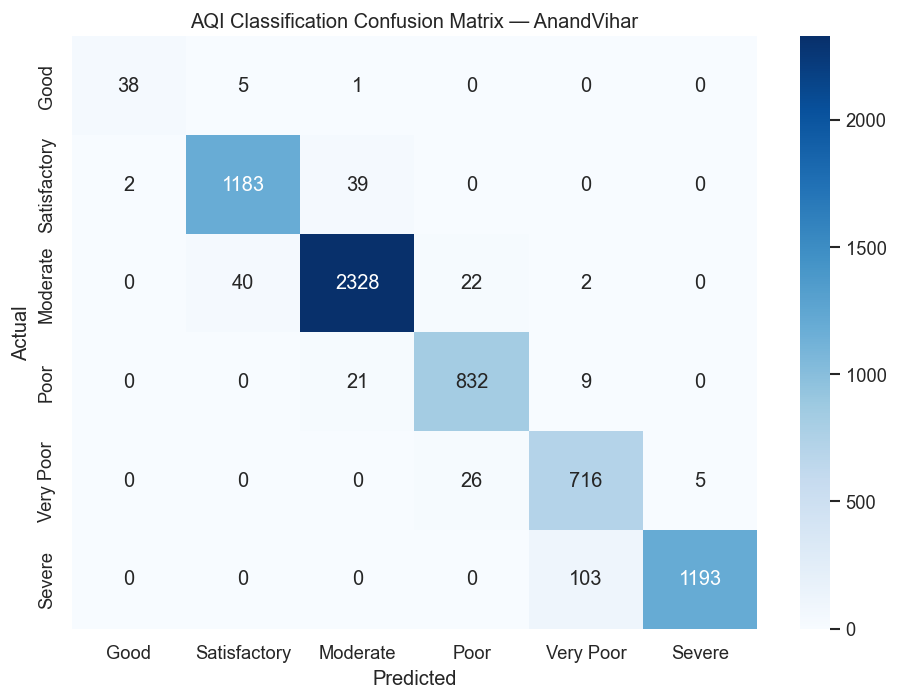

In [51]:
y_true_class = categorize_aqi(y_test.values.flatten())
y_pred_class = categorize_aqi(pred_recursive.flatten())

present_labels = [l for l in cat_order if l in y_true_class or l in y_pred_class]

acc  = accuracy_score(y_true_class, y_pred_class)
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec  = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print('Classification Metrics (AQI Categories — Recursive Forecast):')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)\n')
print('Classification Report:')
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels, yticklabels=present_labels, ax=ax)
ax.set_title(f'AQI Classification Confusion Matrix — {STATION_NAME}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'images/xgboost_confusion_matrix_{STATION_NAME.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Actual vs Predicted Scatter

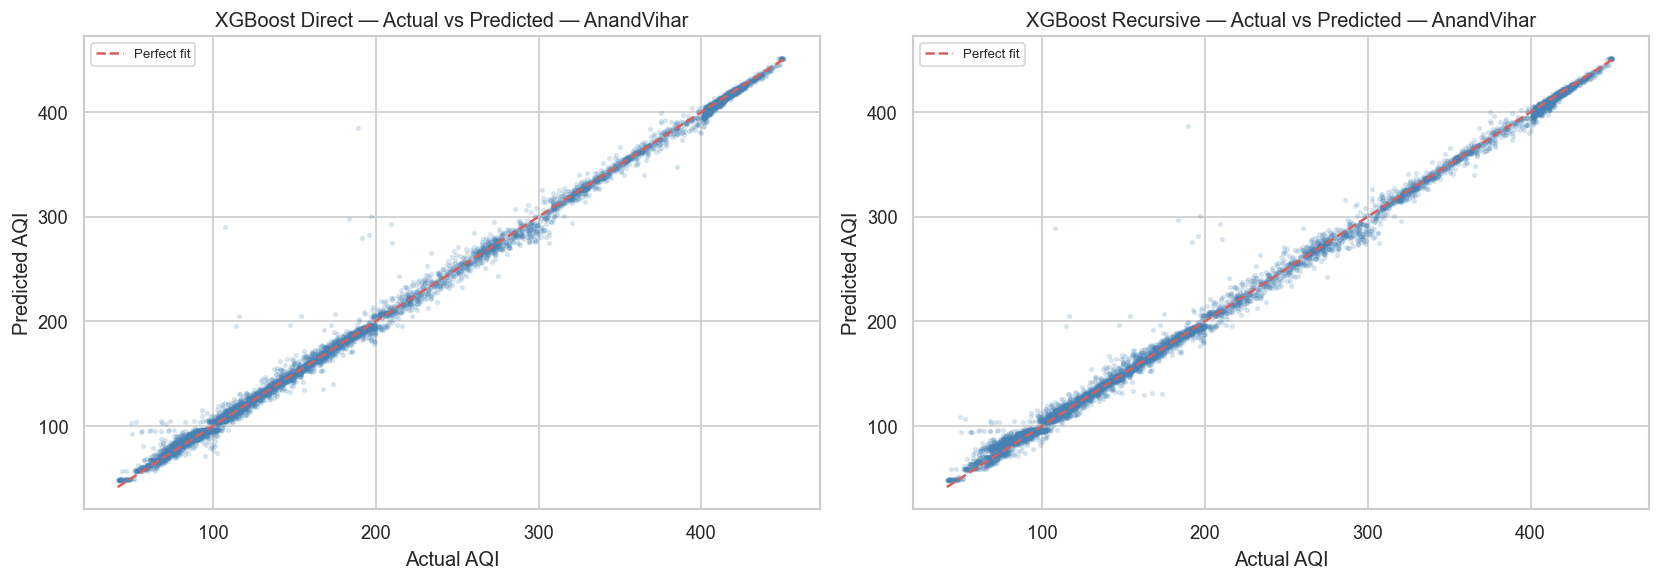

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, label in zip(axes,
                             [pred_direct, pred_recursive],
                             ['Direct', 'Recursive']):
    ax.scatter(y_test.values, preds, alpha=0.15, s=5, color='steelblue')
    lim = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.set_title(f'XGBoost {label} — Actual vs Predicted — {STATION_NAME}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'images/xgboost_scatter_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

## 12. Residual Analysis

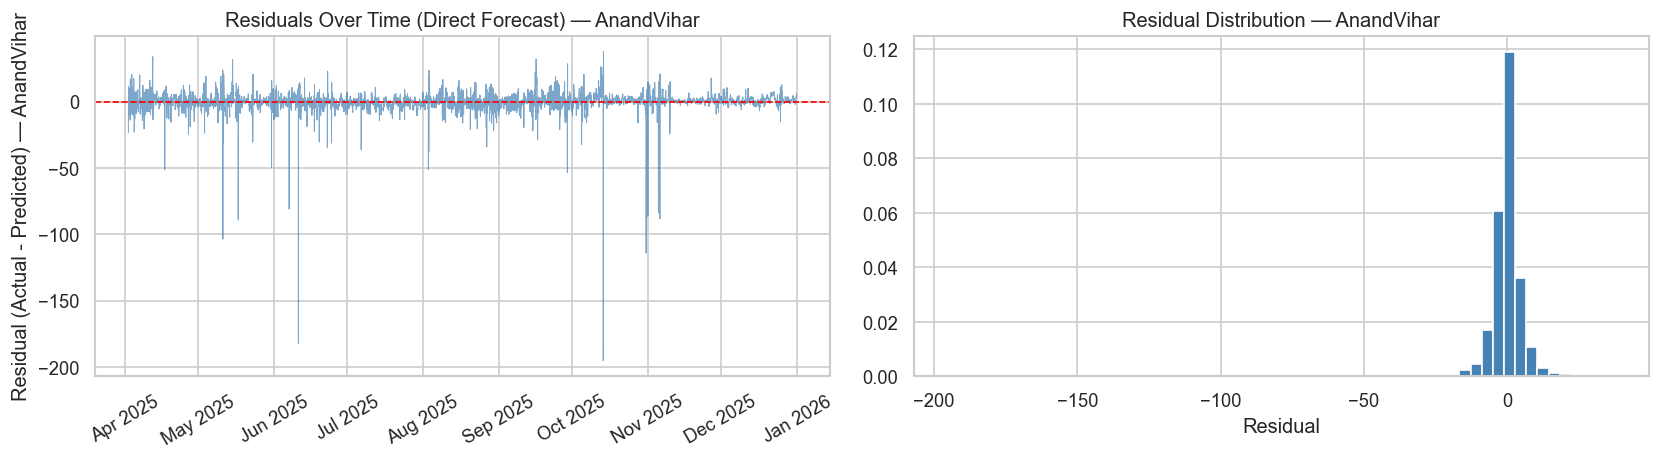

Mean residual : -0.1475
Std  residual : 6.8403


In [53]:
residuals = y_test.values - pred_direct

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(y_test.index, residuals, lw=0.6, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', lw=1, linestyle='--')
axes[0].set_title(f'Residuals Over Time (Direct Forecast) — {STATION_NAME}')
axes[0].set_ylabel(f'Residual (Actual - Predicted) — {STATION_NAME}')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True)
axes[1].set_title(f'Residual Distribution — {STATION_NAME}')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig(f'images/xgboost_residuals_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

print(f'Mean residual : {residuals.mean():.4f}')
print(f'Std  residual : {residuals.std():.4f}')

## 13. Save Model

In [57]:
import joblib

model_path = os.path.join(OUTPUT_DIR, f'{STATION_NAME.lower()}_xgboost_aqi.pkl')
joblib.dump(model, model_path)
print(f'Model saved → {model_path}')

# Save feature list for reproducibility
import json
os.makedirs('outputs', exist_ok=True)
feat_path = os.path.join('outputs', f'{STATION_NAME}_xgboost_features.json')
with open(feat_path, 'w') as fp:
    json.dump(feature_cols, fp, indent=2)
print(f'Feature list saved → {feat_path}')


Model saved → saved_models\anandvihar_xgboost_aqi.pkl
Feature list saved → outputs\AnandVihar_xgboost_features.json
